In [1]:
%load_ext autoreload
%autoreload 2

import torch
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from esm.tokenization.sequence_tokenizer import (
    EsmSequenceTokenizer,
)
tokenizer = EsmSequenceTokenizer()
import transformers
from go_ml.train_utils import get_enzyme_df, enzyme_iterator
enzyme_df = get_enzyme_df()
enzyme_l = list(enzyme_iterator(enzyme_df, tokenizer))
annot_ind = [e['annot_ind'] for e in enzyme_l]

In [ ]:
from go_ml.masking import *

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

from esm.utils.structure.protein_chain import ProteinChain
from esm.utils.constants.esm3 import SEQUENCE_VOCAB
from esm.models.esm3 import ESM3
from esm.sdk.api import (
    ESMProtein,
    GenerationConfig,
)
# model =  ESM3.from_pretrained("esm3_sm_open_v1", device=torch.device(DEVICE)).eval()

from esm.tokenization.function_tokenizer import (
    InterProQuantizedTokenizer as EsmFunctionTokenizer,
)
from esm.tokenization.sequence_tokenizer import (
    EsmSequenceTokenizer,
)
from esm.utils.constants.esm3 import (
    SEQUENCE_MASK_TOKEN,
)
from esm.utils.structure.protein_chain import ProteinChain
from esm.utils.types import FunctionAnnotation

tokenizer = EsmSequenceTokenizer()
seq = enzyme_df['Sequence'].iloc[0]
protein_prompt = ESMProtein(sequence=seq)
protein_tensor = model.encode(protein_prompt)
seq_ind, ln = protein_tensor.sequence, len(seq)

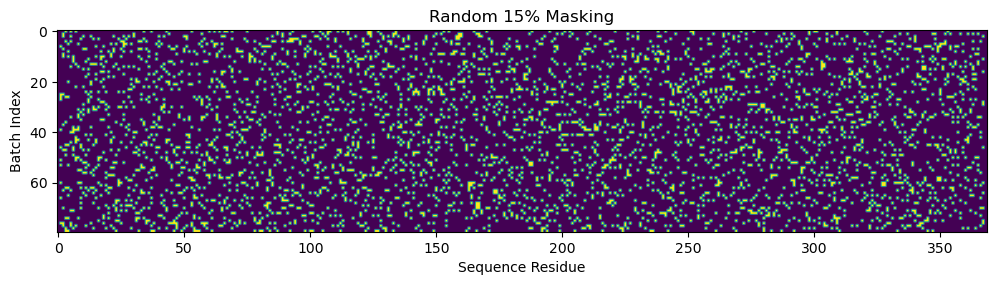

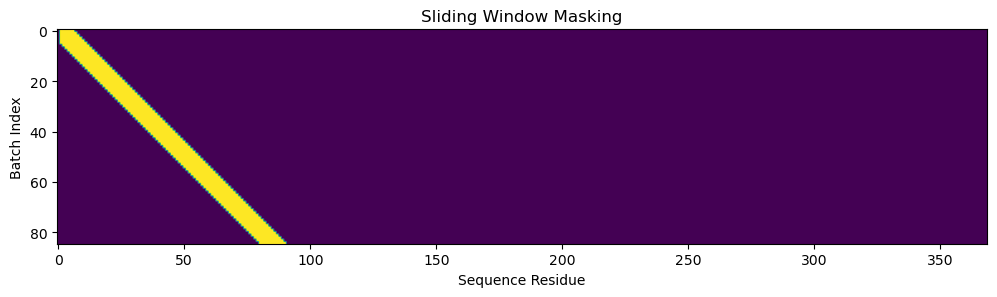

In [ ]:
batch, batch_inds, mut_inds = mask_perc(seq_ind, SEQUENCE_MASK_TOKEN, residue_coverage=12)
batch = batch.cpu()
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.imshow(batch == SEQUENCE_MASK_TOKEN)
ax.set_xlabel('Sequence Residue')
ax.set_ylabel('Batch Index')
ax.set_title('Random 15% Masking')
fig.show()

batch, batch_inds, mut_inds = mask_indiv_neighborhood(seq_ind, SEQUENCE_MASK_TOKEN, n_rad=5)
batch = batch.cpu()
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.imshow(batch[:85, :] == SEQUENCE_MASK_TOKEN)
ax.set_xlabel('Sequence Residue')
ax.set_ylabel('Batch Index')
ax.set_title('Sliding Window Masking')
fig.show()

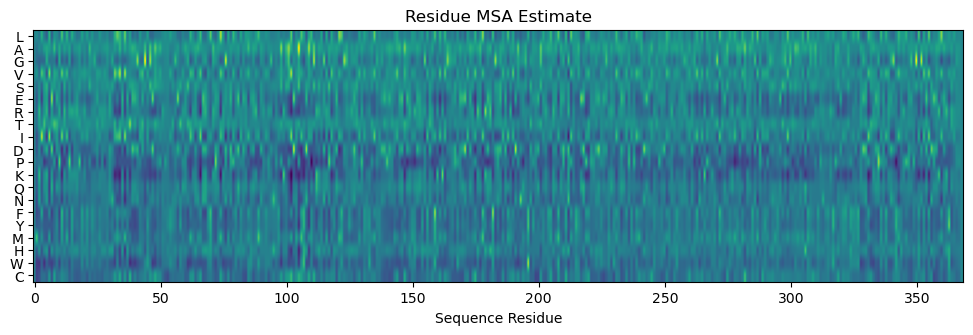

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(logit_eval_dict['base'][0][:, 4:24].T, aspect=5)
ax.set_xlabel('Sequence Residue')
ax.set_yticks(np.arange(20), AA_str)
ax.set_title('Residue MSA Estimate')
fig.show()

In [3]:
p = torch.rand((100, 20))
p /= p.sum(dim=1, keepdim=True)
cu = torch.ones(20) / 20

entr = (torch.log(p)*p).sum(dim=1)
from torch.nn.functional import kl_div
# kl = kl_div(torch.log(p), torch.tile(cu, (100, 1)), log_target=False, reduction='none').sum(dim=1) - 3
ref_p = torch.tile(cu, (100, 1))
kl = (p*(torch.log(p)-torch.log(ref_p))).sum(dim=1)


In [4]:
import json
with open('/home/andrew/GO_interp/data/uniprot_aa_freq.json', 'r') as f:
    aa_freq = json.load(f)
vi = {i: a for a, i in tokenizer.get_vocab().items()}
AA_str = [vi[i] for i in range(4, 24)]
aa_distr = np.array([aa_freq[a] for a in AA_str])
aa_distr = aa_distr
aa_distr /= aa_distr.sum()

def logit_entropy(logit_l, base_ind, max_len=800):
    max_entr = np.log(len(base_ind))
    entropy_val = np.zeros((len(logit_l), max_len+1)) + max_entr
    for i, bert_logit in enumerate(logit_l):
        sl = bert_logit.shape[0]-2
        p = torch.softmax(bert_logit.cpu()[:, base_ind], dim=-1)
        res_entropy_imp = -(torch.log(p)*p).sum(dim=-1)
        entropy_val[i, 1:sl+1] = res_entropy_imp[1:-1].numpy()
    return entropy_val

from torch.nn.functional import kl_div
def logit_kl(logit_l, base_ind, base_distr, max_len=800):
    kl_val = np.zeros((len(logit_l), max_len+1))
    for i, bert_logit in enumerate(logit_l):
        sl = bert_logit.shape[0]-2
        p = torch.log_softmax(bert_logit.cpu()[:, base_ind], dim=-1)
        aa_base_distr = torch.tile(base_distr, (bert_logit.shape[0], 1))
        res_kl_div = (p*(torch.log(p)-torch.log(aa_base_distr))).sum(dim=1)
        # res_entropy_imp = -(torch.log(p)*p).sum(dim=-1)
        kl_val[i, 1:sl+1] = res_kl_div[1:-1].numpy()
    return kl_val


In [31]:
with open('eval_logits/esm3_csa_logits.pkl', 'rb') as f:
   logit_eval_dict = pickle.load(f)
base_ind = list(range(4, 24))
entropy_eval_dict = {k:logit_entropy(ll, base_ind, max_len=800) for k, ll in logit_eval_dict.items()}
kl_eval_dict = {k:logit_kl(ll, base_ind, torch.FloatTensor(aa_distr), max_len=800) for k, ll in logit_eval_dict.items()}

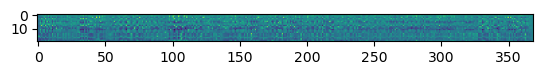

In [32]:
seq_len = np.array([len(e['seq']) for e in enzyme_l])
annot_ind = [e['annot_ind'] for e in enzyme_l]
token_labels = np.zeros_like(entropy_eval_dict['base'])
for r, ti in enumerate(annot_ind):
    ti_f = [i for i in ti if i <= 800]
    token_labels[r, ti_f] = 1

from go_ml.eval_utils import mean_reciprocal_rank, mean_percent_rank, roc_stats, mean_reciprocal_rank_corrected

for k, eeval in entropy_eval_dict.items():
    eeval = -torch.tensor(eeval)
    # mrr = mean_reciprocal_rank(eeval, annot_ind)
    mrr = mean_reciprocal_rank_corrected(eeval, annot_ind)
    mpr = mean_percent_rank(eeval, torch.LongTensor(seq_len), annot_ind)
    roc = roc_stats(eeval, seq_len, annot_ind)
    print(f'{k} stats', roc, mrr, mpr)

func_cond stats 0.808353092652038 tensor(0.3633) tensor(0.1996)
base stats 0.8081927224410771 tensor(0.3669) tensor(0.1998)
mask_nc3 stats 0.8071589825523323 tensor(0.3717) tensor(0.1995)
mask_nc10 stats 0.7896723873893874 tensor(0.3636) tensor(0.2158)
perc stats 0.8097456304601042 tensor(0.3749) tensor(0.1975)
unmasked stats 0.801644599475235 tensor(0.3482) tensor(0.2058)


In [22]:
from go_ml.eval_utils import mean_reciprocal_rank, mean_percent_rank, roc_stats, mean_reciprocal_rank_corrected
with open('../presentation/esm2_csa_logits.pkl', 'rb') as f:
   logit_eval_dict = pickle.load(f)
base_ind = list(range(4, 24))
entropy_eval_dict = {k:logit_entropy(ll, base_ind, max_len=800) for k, ll in logit_eval_dict.items()}

In [ ]:

seq_len = np.array([len(e['seq']) for e in enzyme_l])
annot_ind = [e['annot_ind'] for e in enzyme_l]
token_labels = np.zeros_like(entropy_eval_dict['base'])
for r, ti in enumerate(annot_ind):
    ti_f = [i for i in ti if i <= 800]
    token_labels[r, ti_f] = 1

for k, eeval in entropy_eval_dict.items():
    print(eeval.shape, len(seq_len))
    eeval = -torch.tensor(eeval)
    mrr = mean_reciprocal_rank(eeval, annot_ind)
    mpr = mean_percent_rank(eeval, torch.LongTensor(seq_len), annot_ind)
    roc = roc_stats(eeval, seq_len, annot_ind)
    print(f'{k} stats', roc, mrr, mpr)

# func_cond stats tensor(0.1336) tensor(0.1982)
# base stats tensor(0.1344) tensor(0.1981)
# mask_nc3 stats tensor(0.1366) tensor(0.1977)
# mask_nc10 stats tensor(0.1273) tensor(0.2134)
# perc stats tensor(0.1371) tensor(0.1956)
# unmasked stats tensor(0.1256) tensor(0.2036)


# base stats tensor(0.1404) tensor(0.1866)
# mask_nc3 stats tensor(0.1399) tensor(0.1899)
# mask_nc10 stats tensor(0.1109) tensor(0.2353)
# perc stats tensor(0.1410) tensor(0.1876)
# unmasked stats tensor(0.0966) tensor(0.2092)

(785, 801) 731


RuntimeError: The size of tensor a (785) must match the size of tensor b (731) at non-singleton dimension 0

In [7]:
seq_len = np.array([len(e['seq']) for e in enzyme_l])
annot_ind = [e['annot_ind'] for e in enzyme_l]
token_labels = np.zeros_like(kl_eval_dict['base'])
for r, ti in enumerate(annot_ind):
    ti_f = [i for i in ti if i <= 800]
    token_labels[r, ti_f] = 1

from go_ml.eval_utils import mean_reciprocal_rank, mean_percent_rank, roc_stats, mean_reciprocal_rank_corrected

for k, eeval in kl_eval_dict.items():
    eeval = torch.tensor(eeval)
    # mrr = mean_reciprocal_rank(eeval, annot_ind)
    mrr = mean_reciprocal_rank_corrected(eeval, annot_ind)
    mpr = mean_percent_rank(eeval, torch.LongTensor(seq_len), annot_ind)
    roc = roc_stats(eeval, seq_len, annot_ind)
    print(f'{k} stats', roc, mrr, mpr)

ValueError: Input contains NaN.

func_cond stats 0.808353092652038 tensor(0.3633) tensor(0.1996)
base stats 0.8081927224410771 tensor(0.3669) tensor(0.1998)
mask_nc3 stats 0.8071589825523323 tensor(0.3717) tensor(0.1995)
mask_nc10 stats 0.7896723873893874 tensor(0.3636) tensor(0.2158)
perc stats 0.8097456304601042 tensor(0.3749) tensor(0.1975)
unmasked stats 0.801644599475235 tensor(0.3482) tensor(0.2058)


In [ ]:
import json
def get_df1(df_url="/home/andrew/GO_interp/data/enzyme_dataset_seq.csv", 
                  train_path="/home/andrew/cafa5_team/data/"):
    enzyme_df= pd.read_csv(df_url)
    enzyme_df= enzyme_df[~enzyme_df['Sequence'].isna()]
    enzyme_go_terms = [gt.split("'")[1] for gt in enzyme_df['GOTerm']]
    with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
        go_terms = json.load(f)
    term_ind_map = {t:i for i, t in enumerate(go_terms)}
    enzyme_df['GOTerm'] = enzyme_go_terms
    enzyme_df= enzyme_df[enzyme_df['GOTerm'].isin(term_ind_map)]
    enzyme_term_index = [term_ind_map[t] for t in enzyme_df['GOTerm']]
    enzyme_df['GOTermIndex'] = enzyme_term_index
    annotated_indices = [list(filter(lambda x: x < min(1024, len(seq)), map(int, x[1:-1].split(',')))) for x, seq in zip(enzyme_df['AnnotatedIndices'], enzyme_df['Sequence'])]
    enzyme_df['AnnotatedIndices'] = annotated_indices
    return enzyme_df

def get_df2(df_url="/home/andrew/GO_interp/data/enzyme_dataset_seq.csv", 
                  train_path="/home/andrew/cafa5_team/data/", max_len=800):
    enzyme_df= pd.read_csv(df_url)
    enzyme_df= enzyme_df[~enzyme_df['Sequence'].isna()]
    enzyme_go_terms = [gt.split("'")[1] for gt in enzyme_df['GOTerm']]
    with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
        go_terms = json.load(f)
    term_ind_map = {t:i for i, t in enumerate(go_terms)}
    enzyme_df['GOTerm'] = enzyme_go_terms
    enzyme_df= enzyme_df[enzyme_df['GOTerm'].isin(term_ind_map)]
    enzyme_term_index = [term_ind_map[t] for t in enzyme_df['GOTerm']]
    enzyme_df['GOTermIndex'] = enzyme_term_index
    annotated_indices = [list(filter(lambda x: x < min(1024, len(seq)), map(int, x[1:-1].split(',')))) for x, seq in zip(enzyme_df['AnnotatedIndices'], enzyme_df['Sequence'])]
    enzyme_df['AnnotatedIndices'] = annotated_indices
    enzyme_df = enzyme_df[[len(annot_ind) > 0 for annot_ind in annotated_indices]]
    enzyme_df = enzyme_df[[len(seq) <= max_len for seq in enzyme_df['Sequence']]]
    return enzyme_df

enzyme_df1 = get_df1()
enzyme_df2 = get_df2()
inc_pid = set(enzyme_df2['UniprotID'])
inc_mask = np.array([x in inc_pid for x in enzyme_df1['UniprotID']])
inc_ind = np.nonzero(inc_mask)[0]

with open('esm3_csa_logits_1024.pkl', 'rb') as f:
   logit_eval_dict = pickle.load(f)
logit_eval_dict_800 = {k:[ll[i] for i in inc_ind] for k, ll in logit_eval_dict.items()}
with open('esm3_csa_logits.pkl', 'wb') as f:
   pickle.dump(logit_eval_dict_800, f)

In [ ]:
from go_ml.esm3.viz_utils import get_pssm_display, get_score_display
import bokeh as bh
import bokeh.plotting
bokeh.io.output_notebook()

seq = enzyme_l[12]['seq']
logits_cond = logit_eval_dict['func_cond'][12]
logits_base = logit_eval_dict['base'][12]

pssm_disp_cond = get_pssm_display(seq, logits_cond.numpy()[:, 4:24])
pssm_disp_base = get_pssm_display(seq, logits_base.numpy()[:, 4:24])

pssm_diff = get_score_display(seq[:], (logits_cond - logits_base).numpy()[:, 4:24])
bh.plotting.show(pssm_diff)

Loading BokehJS ...

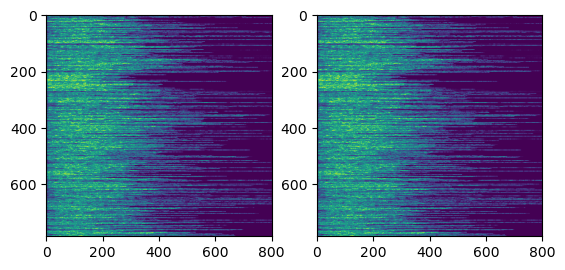

In [21]:
fig, ax = plt.subplots(1, 2)
ax[0].imshow(-entropy_eval_dict['base'])
ax[1].imshow(-entropy_eval_dict['func_cond'])
# ax[2].imshow(-entropy_eval_dict['low_pass'])
fig.show()

In [10]:
from scipy.signal import convolve
avg_filter = np.array([1, 1, 1, 1, 0, 1, 1, 1, 1], dtype=float)
avg_filter /= avg_filter.sum()
def low_pass(seq_score, avg_filter):
    return convolve(seq_score, avg_filter, mode='same')

entropy_eval_dict['low_pass'] = np.array([low_pass(ev, avg_filter) for ev in entropy_eval_dict['base']])

In [189]:
entropy_eval_dict['delta'] = (entropy_eval_dict['base'] - entropy_eval_dict['low_pass'])

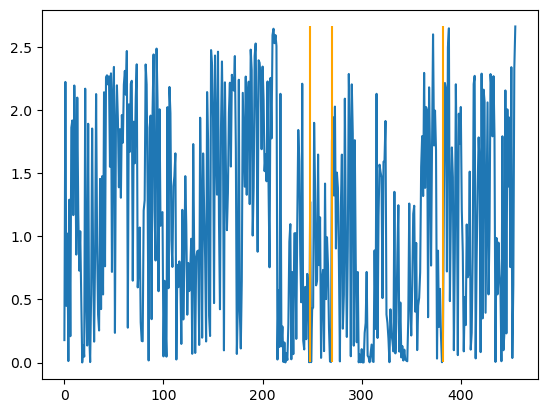

In [7]:
test_pi = 405
seq = enzyme_l[test_pi]['seq']
# logits_cond = logit_eval_dict['func_cond'][test_pi].numpy()[:, 4:24]
# logits_base = logit_eval_dict['base'][test_pi].numpy()[:, 4:24]
annot_ind = enzyme_l[test_pi]['annot_ind']
# plt.plot(np.max(np.abs(logits_base - logits_cond), axis=1))
entropy_val = entropy_eval_dict['base'][test_pi][1:len(seq)]
plt.plot(entropy_val)
plt.vlines(annot_ind, np.min(entropy_val), np.max(entropy_val), color='orange')
plt.show()

In [8]:
from go_ml.eval_utils import mean_reciprocal_rank, mean_percent_rank, roc_stats

with open('../presentation/esm2_csa_logits.pkl', 'rb') as f:
   logit_eval_dict = pickle.load(f)

base_ind = list(range(4, 24))
entropy_eval_dict = {k:logit_entropy(ll, base_ind, max_len=800) for k, ll in logit_eval_dict.items()}

for k, eeval in entropy_eval_dict.items():
    eeval = -torch.tensor(eeval)
    mrr = mean_reciprocal_rank(eeval, annot_ind)
    mpr = mean_percent_rank(eeval, torch.LongTensor(seq_len), annot_ind)
    roc = roc_stats(-entropy_eval_dict['base'], seq_len, annot_ind)
    print(f'{k} stats', roc, mrr, mpr)

# func_cond stats tensor(0.1336) tensor(0.1982)
# base stats tensor(0.1344) tensor(0.1981)
# mask_nc3 stats tensor(0.1366) tensor(0.1977)
# mask_nc10 stats tensor(0.1273) tensor(0.2134)
# perc stats tensor(0.1371) tensor(0.1956)
# unmasked stats tensor(0.1256) tensor(0.2036)


# base stats tensor(0.1404) tensor(0.1866)
# mask_nc3 stats tensor(0.1399) tensor(0.1899)
# mask_nc10 stats tensor(0.1109) tensor(0.2353)
# perc stats tensor(0.1410) tensor(0.1876)
# unmasked stats tensor(0.0966) tensor(0.2092)

RuntimeError: The size of tensor a (785) must match the size of tensor b (731) at non-singleton dimension 0